In [37]:
import numpy as np

In [38]:
def linear(z, derivative=False):
    a = z
    if(derivative):
        da = np.ones(z.shape)
        return a, da
    return a

def sigmoid(z, derivative=False): # logistic
    a = 1 / (1 + np.exp(-z))
    if(derivative):
        da = a * (1 - a)
        return a, da
    return a

def softmax(z, derivative=False):
    e = np.exp(z - np.max(z, axis=0))
    a = e / np.sum(e, axis=0)
    if(derivative):
        da = np.ones(z.shape)
        return a, da
    return a

In [39]:
class OLN: # One Layer Network

    def __init__(self, n_inputs, n_outputs, activation_fnc):
        self.w = -1 + 2 * np.random.rand(n_outputs, n_inputs)
        self.b = -1 + 2 * np.random.rand(n_outputs, 1)
        self.f = activation_fnc

    def predict(self, X): # Propagation
        Z = np.dot(self.w, X) + self.b
        return self.f(Z)
    
    def fit(self, X, Y, epochs=200, lr=0.1):
        p = X.shape[1]
        for _ in range(epochs):
            Z = np.dot(self.w, X) + self.b
            Y_est, dY = self.f(Z, derivative=True)
            # BGD
            local_grad = (Y - Y_est) * dY
            self.w += (lr / p) * np.dot(local_grad, X.T)
            self.b += (lr / p) * np.sum(local_grad, axis=1).reshape(-1, 1)

In [40]:
minx = -5
maxx = 5

classes = 4
p_per_class = 20

X = np.zeros((2, classes * p_per_class))
Y = np.zeros((classes, classes * p_per_class))

for i in range(classes):
    seed = minx + (maxx - minx) * np.random.rand(2, 1)

    X[:, i * p_per_class : (i + 1) * p_per_class] = np.random.rand(2, 1)
    Y[i, i * p_per_class : (i + 1) * p_per_class] = np.ones((1 , p_per_class))

In [41]:
one_layer_network = OLN(2, classes, softmax)
one_layer_network.fit(X, Y, epochs = 300, lr=1)

Y_pred = one_layer_network.predict(X)

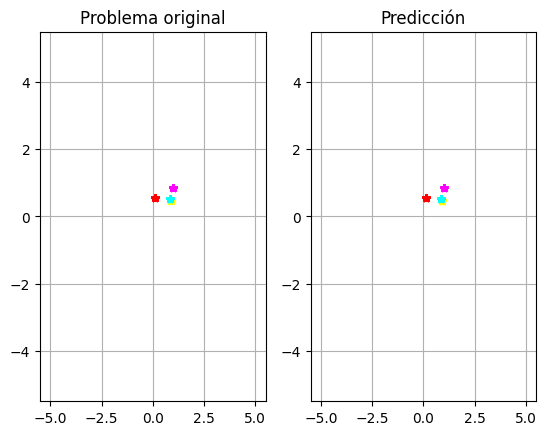

In [42]:
import matplotlib.pyplot as plt

cm = [[1, 1, 0], [1, 0, 1], [0, 1, 1], [1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 1, 1], [0, 0, 0]]

ax1 = plt.subplot(1, 2, 1)
y_c = np.argmax(Y, axis = 0)

for i in range(X.shape[1]):
    ax1.plot(X[0, i], X[1, i], '*', c = cm[y_c[i]])

ax1.axis([-5.5, 5.5, -5.5, 5.5])
ax1.set_title('Problema original')
ax1.grid()

ax2 = plt.subplot(1, 2, 2)
y_c = np.argmax(Y_pred, axis = 0)

for i in range(X.shape[1]):
    ax2.plot(X[0, i], X[1, i], '*', c = cm[y_c[i]])

ax2.axis([-5.5, 5.5, -5.5, 5.5])
ax2.set_title('Predicción')
ax2.grid()